# 01 - Baseline, Logistic Regression

Logistic Regression is the first model we try, and deliberately so.
Before reaching for complex architectures, we want to know how much
a linear classifier can extract from raw windowed CSI features.
If a linear boundary already achieves strong F1, it tells us the
classes are well separated in feature space and complexity adds risk
of overfitting rather than value.

**This notebook answers: how does a linear model scale with window size, and which features actually drive the decision?**

---

## Notebook structure

1. Load data and define windows
2. Train LR on each window size W1 through W4
3. Evaluate on held-out sessions
4. Ablation plot F1 across window sizes
5. Feature importance, which subcarriers and scalar features matter most

In [15]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import os
import importlib

SAVE_DIR = "full-study-outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

import utils
importlib.reload(utils)
from utils import (
    FEATURE_COLS, WINDOW_SIZES, TEST_SESSIONS,
    load_data, make_windows, session_split, evaluate, plot_ablation,
)

print("FEATURE_COLS :", len(FEATURE_COLS), "features")
print("WINDOW_SIZES :", WINDOW_SIZES)
print("TEST_SESSIONS:", TEST_SESSIONS)

FEATURE_COLS : 55 features
WINDOW_SIZES : {'W1_snapshot': 1, 'W2_1s': 80, 'W3_5s': 400, 'W4_10s': 800}
TEST_SESSIONS: ['session5_morning_empty', 'session7_morning_occupied']


## Load Data

In [16]:
df = load_data()
print(f"Labels : {df['label'].value_counts().to_dict()}")

Labels : {'empty': 189933, 'occupied': 186581}


## Training

For Logistic Regression each window is flattened into a single vector
(window_size × 55 features). A `StandardScaler` is included in the pipeline
LR with L2 regularisation is sensitive to feature scale, and the amplitude
columns and scalar features live on very different numerical ranges.

We train one model per window size and record F1, AUC, and accuracy on the
held out test sessions.

In [17]:
results = {}
models  = {}

for wname, wsize in WINDOW_SIZES.items():
    X, y, sessions = make_windows(df, window_size=wsize)
    X_flat = X.reshape(len(X), -1)

    X_train, X_test, y_train, y_test = session_split(X_flat, y, sessions)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr",     LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ])
    model.fit(X_train, y_train)

    y_pred  = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    print(f"\n{wname}  (train={len(y_train):,}  test={len(y_test):,})")
    metrics = evaluate(y_test, y_pred, y_score)
    results[wname] = metrics
    models[wname]  = (model, wsize)


W1_snapshot  (train=292,364  test=84,150)
  Acc=0.7605  F1=0.8231  Prec=0.8444  Rec=0.8028  AUC=0.8224

W2_1s  (train=3,650  test=1,051)
  Acc=0.7812  F1=0.8559  Prec=0.7878  Rec=0.9369  AUC=0.9107

W3_5s  (train=726  test=209)
  Acc=0.7464  F1=0.8030  Prec=0.8710  Rec=0.7448  AUC=0.8149

W4_10s  (train=360  test=104)
  Acc=0.7404  F1=0.7907  Prec=0.8947  Rec=0.7083  AUC=0.8038


## Results

| Window | Train windows | Test windows | F1 | AUC |
|---|---|---|---|---|
| W1 snapshot | 292,364 | 84,150 | 0.8231 | 0.8224 |
| W2 ~1 s | 3,650 | 1,051 | **0.8559** | **0.9107** |
| W3 ~5 s | 726 | 209 | 0.8030 | 0.8149 |
| W4 ~10 s | 360 | 104 | 0.7907 | 0.8038 |

W2 peaks 80-row averaging smooths out per measurement noise and gives
the linear boundary more signal to work with.

W3 and W4 do not improve further, and the reason is visible in the window
counts non overlapping windows over 376 k rows at stride 400 or 800 yield
fewer than 1,000 training samples. The model has too little data to benefit
from the longer temporal context. This data starvation pattern will appear
across all models and is a structural property of the dataset, not a
model specific failure.

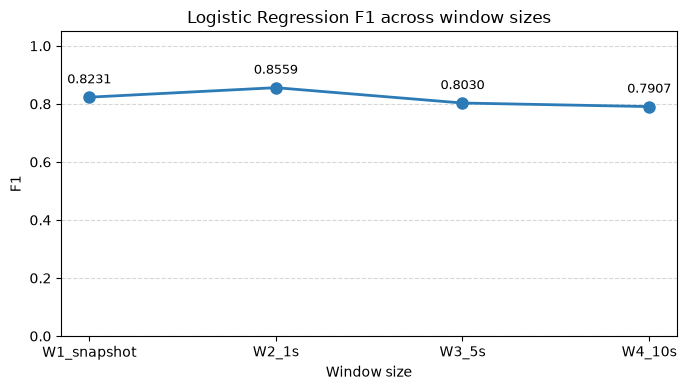

In [18]:
plot_ablation(results, metric="f1", title="Logistic Regression F1 across window sizes",
              save_path=f'{SAVE_DIR}/01_lr_f1_ablation.png')

## Feature Importance

Not all subcarriers carry equal discriminative weight. The 2.4 GHz WiFi band
spans a 20 MHz channel divided across 64 subcarriers; different subcarriers
experience different multipath scattering and path loss. If human presence
disturbs specific parts of the spectrum more strongly, the LR coefficients
will reflect that.

We use the W2 model (best-performing window). Because W2 flattens 80 time
steps x 55 features into a 4,400-dimensional vector, we reshape the
coefficient array back to (80, 55) and average the absolute value across
the time axis. This yields one importance score per feature how much that
feature shifts the decision boundary on average, independent of where in
the window it fires.

**Hypothesis:** the 51 subcarrier amplitudes are not equally informative.
Mid-band subcarriers may carry stronger occupancy signal than edge ones.
The 4 scalar summary features (mean, std, max, energy) may punch above
their count because they compress the entire snapshot into a single value.

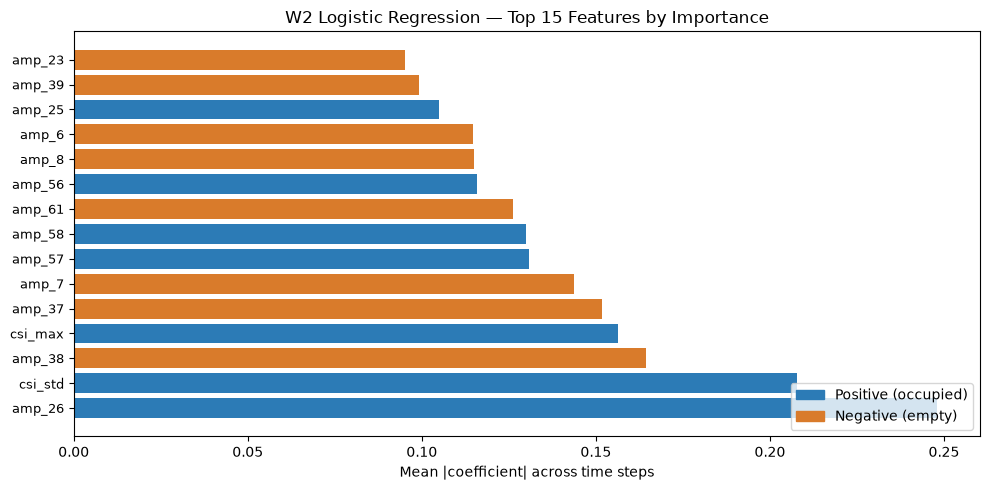


Top 15 features:
   1. amp_26                |coef|=0.2479  => occupied
   2. csi_std               |coef|=0.2077  => occupied
   3. amp_38                |coef|=0.1645  => empty  
   4. csi_max               |coef|=0.1563  => occupied
   5. amp_37                |coef|=0.1518  => empty  
   6. amp_7                 |coef|=0.1438  => empty  
   7. amp_57                |coef|=0.1309  => occupied
   8. amp_58                |coef|=0.1298  => occupied
   9. amp_61                |coef|=0.1263  => empty  
  10. amp_56                |coef|=0.1159  => occupied
  11. amp_8                 |coef|=0.1150  => empty  
  12. amp_6                 |coef|=0.1147  => empty  
  13. amp_25                |coef|=0.1049  => occupied
  14. amp_39                |coef|=0.0993  => empty  
  15. amp_23                |coef|=0.0950  => empty  


In [19]:
w2_model, w2_size = models["W2_1s"]

coefs    = w2_model.named_steps["lr"].coef_[0]
coefs_2d = coefs.reshape(w2_size, len(FEATURE_COLS))

feat_importance = np.abs(coefs_2d).mean(axis=0)
feat_direction  = coefs_2d.mean(axis=0)

top_idx   = np.argsort(feat_importance)[::-1][:15]
top_names = [FEATURE_COLS[i] for i in top_idx]
top_vals  = feat_importance[top_idx]
top_dirs  = feat_direction[top_idx]
colors    = ['#2C7BB6' if d > 0 else '#D97B2B' for d in top_dirs]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(15), top_vals[::-1], color=colors[::-1])
ax.set_yticks(range(15))
ax.set_yticklabels(top_names[::-1], fontsize=9)
ax.set_xlabel("Mean |coefficient| across time steps")
ax.set_title("W2 Logistic Regression — Top 15 Features by Importance")
ax.invert_yaxis()
ax.legend(
    handles=[
        mpatches.Patch(color='#2C7BB6', label="Positive (occupied)"),
        mpatches.Patch(color='#D97B2B', label="Negative (empty)"),
    ],
    loc="lower right",
)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_lr_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 15 features:")
for rank, (name, val, d) in enumerate(zip(top_names, top_vals, top_dirs), 1):
    print(f"  {rank:2d}. {name:<20s}  |coef|={val:.4f}  {'=> occupied' if d > 0 else '=> empty  '}")

## Feature importance interpretation

**Scalar features punch above their count.**
Only 4 scalars vs 51 subcarrier amplitudes, yet `csi_std` (#2) and `csi_max`
(#4) land in the top 5. Both are physically grounded: a person introduces
body induced multipath fluctuations that raise amplitude variance and peak
values within a window. An empty room is stable.

**Subcarrier importance is non uniform and guard band driven.**
`amp_26` is the single most important feature (|coef| = 0.248) the last
active subcarrier before the dropped guard band (idx 27–36). The two
subcarriers immediately after the gap (`amp_37`, `amp_38`) are also highly
ranked. Sharp analog chain transitions at guard band edges amplify sensitivity
to body-induced multipath disruption.

**Sign reversal across the gap.**
`amp_26 => occupied` but `amp_37/38 => empty`: constructive vs destructive
interference on opposite sides of the notch, consistent with a body altering
reflected path phase differently per side.

**Takeaway.** A linear model already extracts physically grounded signal from
raw CSI. CNN and Transformer architectures should exploit the same patterns
especially guard-band edges and `csi_std` more efficiently with
spatial/temporal inductive bias.

## Conclusion

Logistic Regression, a linear model with no temporal reasoning, achieves
F1 = 0.856 at W2. This is the baseline every subsequent model must beat to
justify its added complexity.

The result also confirms that the 55-feature representation (51 subcarrier
amplitudes + 4 scalar summaries) carries genuine discriminative signal a
purely random arrangement of those features would not produce this result
with a linear classifier.

The feature importance analysis adds a second finding: the signal is
structured. Two scalar features (`csi_std`, `csi_max`) and a small cluster
of subcarriers near the guard band boundary dominate the decision. Future
models that can attend to specific subcarrier positions or capture
within-window variance explicitly should improve on this baseline.